In [3]:
import pandas as pd
import numpy as np

# Please place the file "electricity-demand-dataset.csv" in your Google Drive folder named "Data" to run this cell.
# This allows you to access the dataset directly without re-uploading it each time you open the notebook in Google Colab.
# If you prefer not to host the file in Drive, modify the file path to read from the current working directory in Colab instead.

# # --- 1) Mount Drive (Colab) ---
# from google.colab import drive
# drive.mount("/content/drive")

# --- 2) Load CSV from your folder ---
CSV_PATH = "electricity-demand-dataset.csv"
df = pd.read_csv(CSV_PATH)

In [4]:
df.head(30)

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
5,01-Jan-20,5.0,2.0,1.0,2020.0,1.0,10.822571,67.753433,3104.845505
6,01-Jan-20,6.0,2.0,1.0,2020.0,1.0,6.306673,94.912591,3759.476912
7,01-Jan-20,7.0,2.0,1.0,2020.0,1.0,7.464640,74.456860,4114.486001
8,01-Jan-20,8.0,2.0,1.0,2020.0,1.0,14.746876,66.725005,4575.159503
9,01-Jan-20,9.0,2.0,1.0,2020.0,1.0,19.738254,55.036160,4512.169696


In [5]:
df = df.copy()
df_before = df.copy()  # <-- snapshot for "what got fixed"

# =========================
# A) NaN report BEFORE
# =========================
nan_counts_before = df.isna().sum().sort_values(ascending=False)
print("NaN counts per column (BEFORE):")
print(nan_counts_before[nan_counts_before > 0])

rows_with_any_nan_before = df.index[df.isna().any(axis=1)].to_list()
print("\nTotal rows with any NaN (BEFORE):", len(rows_with_any_nan_before))

nan_rows_preview_before = df.loc[rows_with_any_nan_before].copy()
nan_rows_preview_before.insert(0, "row_index", nan_rows_preview_before.index)
display(nan_rows_preview_before.head(50))

NaN counts per column (BEFORE):
hour           11
Humidity       10
dayofweek       9
month           8
Demand          7
Temperature     7
year            5
dayofyear       5
dtype: int64

Total rows with any NaN (BEFORE): 31


,row_index,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
2900,2900,30-Apr-20,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
4854,4854,21-Jul-20,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
10004,10004,20-Feb-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005,10005,20-Feb-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10006,10006,20-Feb-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007,10007,20-Feb-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10162,10162,27-Feb-21,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
17111,17111,13-Dec-21,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
17117,17117,14-Dec-21,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612
17126,17126,14-Dec-21,14.0,1.0,12.0,2021.0,348.0,15.403995,74.011557,NaN


In [6]:
# =========================
# B) Fix Timestamp + hour + ds
# =========================
df["Timestamp_dt"] = pd.to_datetime(
    df["Timestamp"].astype(str).str.strip(),
    format="%d-%b-%y",
    errors="coerce"
)

h = pd.to_numeric(df["hour"], errors="coerce")

for i in range(1, len(h)):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i-1]):
        h.iat[i] = (int(h.iat[i-1]) + 1) % 24

for i in range(len(h) - 2, -1, -1):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i+1]):
        h.iat[i] = (int(h.iat[i+1]) - 1) % 24

still_missing_hour = h.isna().sum()
print("\nMissing hour after neighbor fill:", still_missing_hour)

if still_missing_hour > 0:
    missing_hour_rows = df.index[h.isna()].to_list()
    print("Dropping rows with unresolved hour:", missing_hour_rows[:20], "..." if len(missing_hour_rows) > 20 else "")
    df = df.loc[~h.isna()].copy()
    h = h.loc[~h.isna()].copy()

df["hour"] = h.astype(int)

df["ds"] = df["Timestamp_dt"] + pd.to_timedelta(df["hour"], unit="h")

df["dayofweek"] = df["ds"].dt.weekday
df["month"]     = df["ds"].dt.month
df["year"]      = df["ds"].dt.year
df["dayofyear"] = df["ds"].dt.dayofyear

# =========================
# C) Interpolate continuous columns
# =========================
df = df.sort_values("ds").reset_index(drop=True)

for col in ["Temperature", "Humidity", "Demand"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.set_index("ds")
df[["Temperature", "Humidity", "Demand"]] = df[["Temperature", "Humidity", "Demand"]].interpolate(
    method="time", limit_direction="both"
)
df = df.reset_index()


Missing hour after neighbor fill: 0


In [7]:
# Show the rows (from the UPDATED df) that had at least one NaN BEFORE

cols_to_track = ["Timestamp", "hour", "dayofweek", "month", "year", "dayofyear",
                 "Temperature", "Humidity", "Demand"]
cols_to_track = [c for c in cols_to_track if c in df.columns]

# align df_before to current df (in case some rows were dropped)
df_before_aligned = df_before.loc[df.index].copy()

# row ids that had NaN BEFORE (in tracked cols)
fixed_row_ids = df_before_aligned.index[df_before_aligned[cols_to_track].isna().any(axis=1)].to_list()

print("Number of rows that had NaN BEFORE:", len(fixed_row_ids))
print("Row ids:", fixed_row_ids)

# show only UPDATED values (include ds if available)
show_cols = (["ds"] if "ds" in df.columns else []) + cols_to_track
display(df.loc[fixed_row_ids, show_cols].head(50))

Number of rows that had NaN BEFORE: 31
Row ids: [2900, 4854, 10004, 10005, 10006, 10007, 10162, 17111, 17117, 17126, 21565, 21567, 21569, 21570, 21573, 21581, 32109, 32112, 32117, 32123, 32126, 35707, 35714, 35718, 41491, 41493, 41494, 41503, 43523, 43524, 43533]


,ds,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
2900,2020-04-30 20:00:00,30-Apr-20,20,3,4,2020,121,21.820261,41.353675,5393.127681
4854,2020-07-21 06:00:00,21-Jul-20,6,1,7,2020,203,36.555833,62.779665,6248.349423
10004,2021-02-20 20:00:00,20-Feb-21,20,5,2,2021,51,11.428887,53.262531,4236.292506
10005,2021-02-20 21:00:00,20-Feb-21,21,5,2,2021,51,9.632676,52.322229,3787.233206
10006,2021-02-20 22:00:00,20-Feb-21,22,5,2,2021,51,7.836466,51.381927,3338.173906
10007,2021-02-20 23:00:00,20-Feb-21,23,5,2,2021,51,6.040256,50.441624,2889.114606
10162,2021-02-27 10:00:00,27-Feb-21,10,5,2,2021,58,24.001003,53.303268,4523.253789
17111,2021-12-13 23:00:00,13-Dec-21,23,0,12,2021,347,3.000000,75.457130,3225.225822
17117,2021-12-14 05:00:00,14-Dec-21,5,1,12,2021,348,5.061319,47.215825,2887.848612
17126,2021-12-14 14:00:00,14-Dec-21,14,1,12,2021,348,15.403995,74.011557,4812.459644


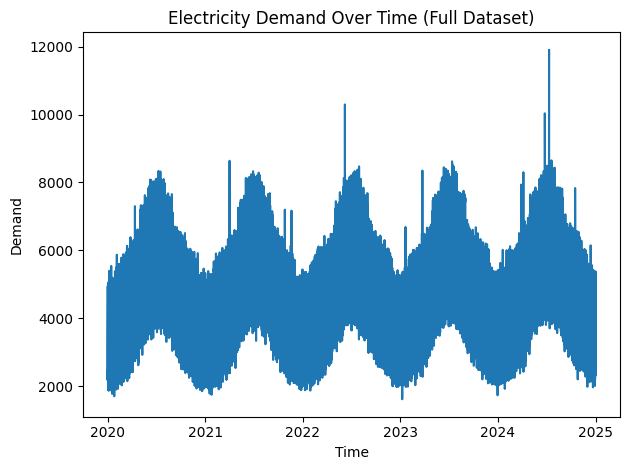

In [8]:
import matplotlib.pyplot as plt

# assumes df already cleaned and has columns: ds, Demand
df_plot = df.sort_values("ds").copy()

plt.figure()
plt.plot(df_plot["ds"], df_plot["Demand"])
plt.title("Electricity Demand Over Time (Full Dataset)")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

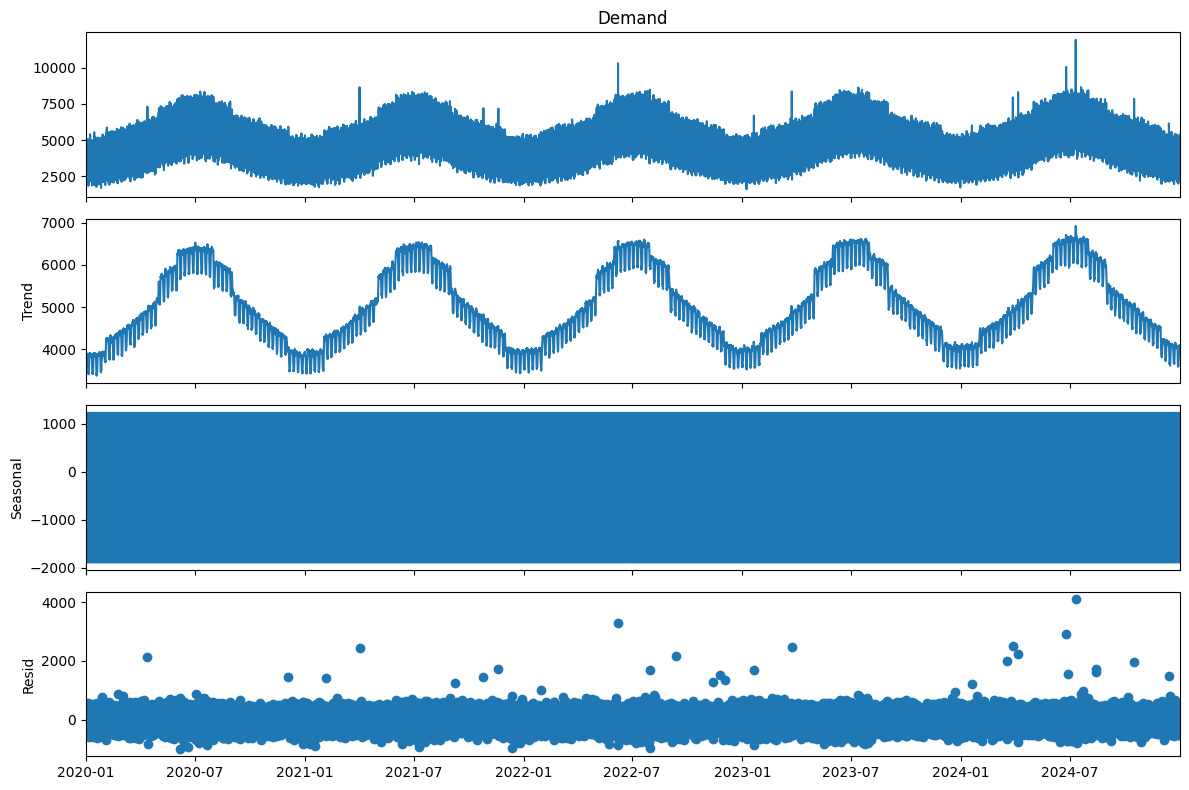

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# assumes df already cleaned and has: ds (datetime), Demand (numeric)
d = df.sort_values("ds").copy()
d = d.set_index("ds")

# hourly data => daily seasonality period = 24
# (you can also try 168 for weekly)
res = seasonal_decompose(d["Demand"], model="additive", period=24)

# plot all components (observed, trend, seasonal, resid)
fig = res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Prophet (calendar-only) 2024:
MAE : 192.98596505190412
RMSE: 254.65699888255773
R^2 : 0.9675080414936665


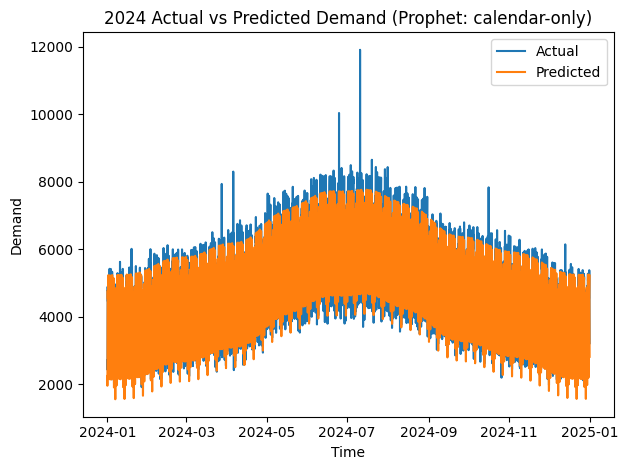

In [10]:
# ===== Prophet (1) Calendar-only: 2020-2023 -> 2024 + plot =====
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = df.sort_values("ds").reset_index(drop=True)
train_df = df[df["ds"].dt.year <= 2023].copy()
test_df  = df[df["ds"].dt.year == 2024].copy()

m1 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
             seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.90)
m1.fit(train_df[["ds", "Demand"]].rename(columns={"Demand": "y"}))

fc1 = m1.predict(test_df[["ds"]])

y_true = test_df["Demand"].to_numpy()
y_pred = fc1["yhat"].to_numpy()

print("Prophet (calendar-only) 2024:")
print("MAE :", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R^2 :", r2_score(y_true, y_pred))

plt.figure()
plt.plot(test_df["ds"], y_true, label="Actual")
plt.plot(test_df["ds"], y_pred, label="Predicted")
plt.title("2024 Actual vs Predicted Demand (Prophet: calendar-only)")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

Prophet (+Temp,+Humidity) 2024:
MAE : 146.0205518771409
RMSE: 200.3621847646002
R^2 : 0.979886105219592


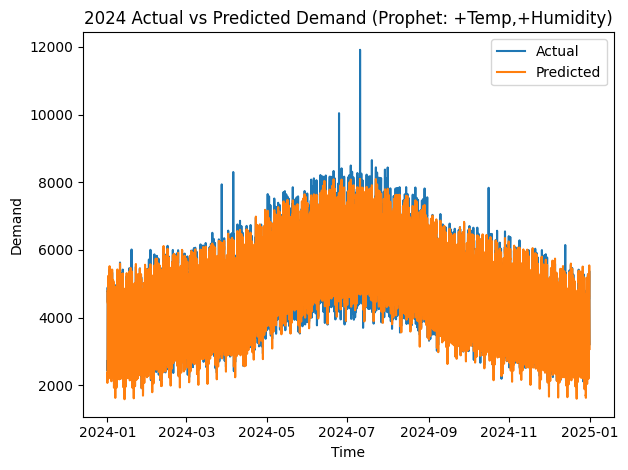

In [11]:
# ===== Prophet (2) Calendar + Weather: 2020-2023 -> 2024 + plot =====
m2 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
             seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.90)
m2.add_regressor("Temperature")
m2.add_regressor("Humidity")

m2.fit(train_df[["ds", "Demand", "Temperature", "Humidity"]].rename(columns={"Demand": "y"}))

fc2 = m2.predict(test_df[["ds", "Temperature", "Humidity"]])

y_pred2 = fc2["yhat"].to_numpy()

print("Prophet (+Temp,+Humidity) 2024:")
print("MAE :", mean_absolute_error(y_true, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred2)))
print("R^2 :", r2_score(y_true, y_pred2))

plt.figure()
plt.plot(test_df["ds"], y_true, label="Actual")
plt.plot(test_df["ds"], y_pred2, label="Predicted")
plt.title("2024 Actual vs Predicted Demand (Prophet: +Temp,+Humidity)")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

Prophet (+Temp,+Humidity,+Demand lags 1..6) 2024:
MAE : 125.58461456336127
RMSE: 175.63801948602625
R^2 : 0.9845438359272612


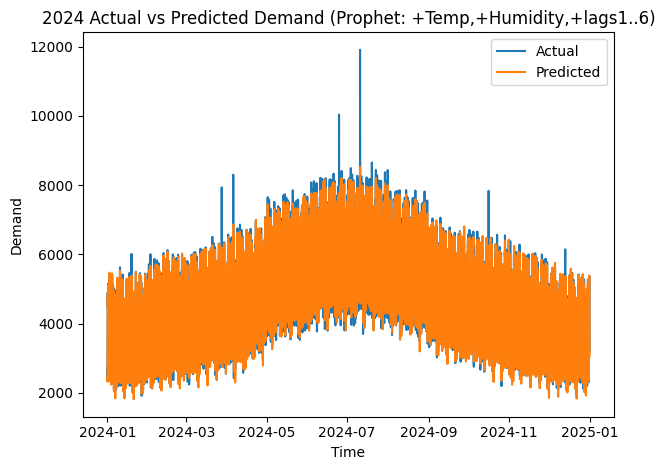

In [12]:
# ===== Prophet (3) Calendar + Weather + Demand lags (1..6 hours): 2020-2023 -> 2024 + plot =====

# 1) Create lag features on the FULL df first (so 2024 lags can use 2023 values)
df_lag = df.sort_values("ds").copy()
for k in range(1, 7):
    df_lag[f"lag{k}"] = df_lag["Demand"].shift(k)

# 2) Recreate train/test from df_lag
train_df_lag = df_lag[df_lag["ds"].dt.year <= 2023].copy()
test_df_lag  = df_lag[df_lag["ds"].dt.year == 2024].copy()

# 3) Drop rows where lag features are missing (first few rows only)
lag_cols = [f"lag{k}" for k in range(1, 7)]
train_df_lag = train_df_lag.dropna(subset=["Demand", "Temperature", "Humidity"] + lag_cols).copy()
test_df_lag  = test_df_lag.dropna(subset=["Demand", "Temperature", "Humidity"] + lag_cols).copy()

# y_true aligned to test_df_lag
y_true3 = test_df_lag["Demand"].to_numpy()

# 4) Fit Prophet with regressors
m3 = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True,
             seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.90)

m3.add_regressor("Temperature")
m3.add_regressor("Humidity")
for c in lag_cols:
    m3.add_regressor(c)

m3.fit(train_df_lag[["ds", "Demand", "Temperature", "Humidity"] + lag_cols].rename(columns={"Demand": "y"}))

# 5) Predict (must supply regressors, including lags)
fc3 = m3.predict(test_df_lag[["ds", "Temperature", "Humidity"] + lag_cols])

y_pred3 = fc3["yhat"].to_numpy()

print("Prophet (+Temp,+Humidity,+Demand lags 1..6) 2024:")
print("MAE :", mean_absolute_error(y_true3, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_true3, y_pred3)))
print("R^2 :", r2_score(y_true3, y_pred3))

plt.figure()
plt.plot(test_df_lag["ds"], y_true3, label="Actual")
plt.plot(test_df_lag["ds"], y_pred3, label="Predicted")
plt.title("2024 Actual vs Predicted Demand (Prophet: +Temp,+Humidity,+lags1..6)")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()